In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

from xgboost import XGBRegressor


project_root = Path.cwd().parent

data_path = (
    project_root
    / "data"
    / "processed"
    / "vic_demand_2024-07_to_2026-06.parquet"
)

df = pd.read_parquet(data_path)

df = df[
    df["SETTLEMENTDATE"] < pd.Timestamp("2026-07-01")
].copy()

df = df.sort_values("SETTLEMENTDATE").reset_index(drop=True)

In [2]:
FORECAST_HORIZON = 6

df["FORECAST_TIME"] = (
    df["SETTLEMENTDATE"]
    + pd.Timedelta(minutes=30)
)

df["target_30m"] = (
    df["TOTALDEMAND"]
    .shift(-FORECAST_HORIZON)
)

# Current and lagged demand
df["demand_current"] = df["TOTALDEMAND"]
df["demand_lag_5m"] = df["TOTALDEMAND"].shift(1)
df["demand_lag_15m"] = df["TOTALDEMAND"].shift(3)
df["demand_lag_30m"] = df["TOTALDEMAND"].shift(6)
df["demand_lag_1h"] = df["TOTALDEMAND"].shift(12)
df["demand_lag_2h"] = df["TOTALDEMAND"].shift(24)

# Same target time on previous comparable days
df["same_time_yesterday"] = (
    df["TOTALDEMAND"]
    .shift(288 - FORECAST_HORIZON)
)

df["same_time_last_week"] = (
    df["TOTALDEMAND"]
    .shift(2016 - FORECAST_HORIZON)
)

# Recent direction of travel
df["change_15m"] = (
    df["TOTALDEMAND"]
    - df["TOTALDEMAND"].shift(3)
)

df["change_30m"] = (
    df["TOTALDEMAND"]
    - df["TOTALDEMAND"].shift(6)
)

df["change_1h"] = (
    df["TOTALDEMAND"]
    - df["TOTALDEMAND"].shift(12)
)

# Recent level and volatility
df["rolling_mean_30m"] = (
    df["TOTALDEMAND"]
    .rolling(6)
    .mean()
)

df["rolling_mean_1h"] = (
    df["TOTALDEMAND"]
    .rolling(12)
    .mean()
)

df["rolling_std_1h"] = (
    df["TOTALDEMAND"]
    .rolling(12)
    .std()
)

# Calendar information for the time being forecast
df["target_hour"] = df["FORECAST_TIME"].dt.hour
df["target_minute"] = df["FORECAST_TIME"].dt.minute
df["target_day_of_week"] = df["FORECAST_TIME"].dt.dayofweek
df["target_month"] = df["FORECAST_TIME"].dt.month
df["target_is_weekend"] = (
    df["target_day_of_week"] >= 5
).astype(int)

In [3]:
features = [
    "demand_current",
    "demand_lag_5m",
    "demand_lag_15m",
    "demand_lag_30m",
    "demand_lag_1h",
    "demand_lag_2h",
    "same_time_yesterday",
    "same_time_last_week",
    "change_15m",
    "change_30m",
    "change_1h",
    "rolling_mean_30m",
    "rolling_mean_1h",
    "rolling_std_1h",
    "target_hour",
    "target_minute",
    "target_day_of_week",
    "target_month",
    "target_is_weekend",
]

model_df = df.dropna(
    subset=features + ["target_30m"]
).copy()

train = model_df[
    model_df["FORECAST_TIME"] < "2026-03-01"
].copy()

validation = model_df[
    (model_df["FORECAST_TIME"] >= "2026-03-01")
    & (model_df["FORECAST_TIME"] < "2026-05-01")
].copy()

test = model_df[
    (model_df["FORECAST_TIME"] >= "2026-05-01")
    & (model_df["FORECAST_TIME"] < "2026-07-01")
].copy()

X_train = train[features]
y_train = train["target_30m"]

X_validation = validation[features]
y_validation = validation["target_30m"]

print(f"Train:      {len(train):,}")
print(f"Validation: {len(validation):,}")
print(f"Test:       {len(test):,}")

Train:      173,087
Validation: 17,568
Test:       17,568


In [4]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(
    X_train,
    y_train,
)

validation["xgb_forecast"] = (
    xgb_model.predict(X_validation)
)

xgb_mae = mean_absolute_error(
    y_validation,
    validation["xgb_forecast"],
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        validation["xgb_forecast"],
    )
)

print(f"XGBoost MAE:  {xgb_mae:.1f} MW")
print(f"XGBoost RMSE: {xgb_rmse:.1f} MW")

XGBoost MAE:  77.2 MW
XGBoost RMSE: 107.5 MW


In [5]:
validation["persistence_forecast"] = (
    validation["demand_current"]
)

persistence_mae = mean_absolute_error(
    validation["target_30m"],
    validation["persistence_forecast"],
)

linear_mae = 107.538958

results = pd.DataFrame(
    {
        "Model": [
            "Persistence",
            "Linear regression",
            "XGBoost",
        ],
        "MAE_MW": [
            persistence_mae,
            linear_mae,
            xgb_mae,
        ],
    }
)

results["Improvement_vs_persistence_%"] = (
    (persistence_mae - results["MAE_MW"])
    / persistence_mae
    * 100
)

results

,Model,MAE_MW,Improvement_vs_persistence_%
0,Persistence,163.641802,0.000000
1,Linear regression,107.538958,34.283932
2,XGBoost,77.245516,52.795975


In [6]:
feature_importance = (
    pd.DataFrame(
        {
            "feature": features,
            "importance": xgb_model.feature_importances_,
        }
    )
    .sort_values(
        "importance",
        ascending=False,
    )
)

feature_importance

,feature,importance
0,demand_current,0.870290
1,demand_lag_5m,0.100783
10,change_1h,0.008671
9,change_30m,0.007504
14,target_hour,0.003450
8,change_15m,0.001343
13,rolling_std_1h,0.001088
17,target_month,0.000874
2,demand_lag_15m,0.000702
15,target_minute,0.000686


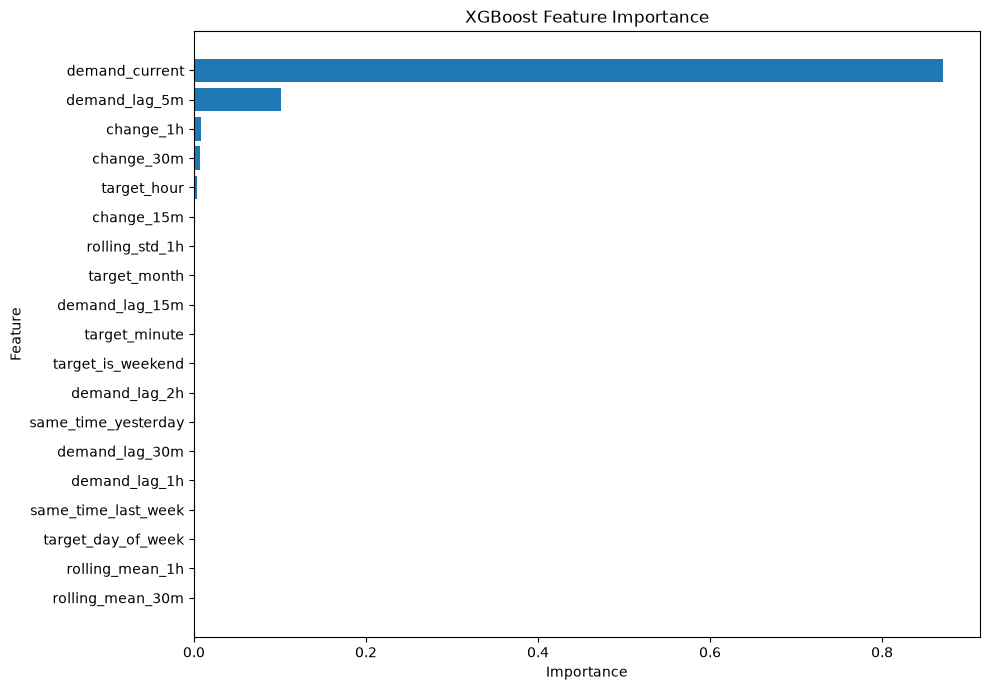

In [7]:
plt.figure(figsize=(10, 7))

plot_importance = feature_importance.sort_values(
    "importance"
)

plt.barh(
    plot_importance["feature"],
    plot_importance["importance"],
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Gradient boosting results

XGBoost substantially improved forecast accuracy over both the persistence
benchmark and linear regression.

Validation performance:

- Persistence MAE: 163.6 MW
- Linear regression MAE: 107.5 MW
- XGBoost MAE: 77.2 MW
- XGBoost RMSE: 107.5 MW

XGBoost reduced MAE by approximately 52.8% relative to persistence and
approximately 28% relative to linear regression.

Built-in feature importance indicates that current demand and the most recent
lagged demand observations provide most of the model's predictive signal.
However, these features are strongly correlated, so feature importance should
not be interpreted as a causal measure of each variable's contribution.

An ablation study is therefore used next to test whether calendar, historical
and rolling-statistic features materially improve forecast accuracy.

In [8]:
recent_features = [
    "demand_current",
    "demand_lag_5m",
    "demand_lag_15m",
    "demand_lag_30m",
    "demand_lag_1h",
    "demand_lag_2h",
    "change_15m",
    "change_30m",
    "change_1h",
]

historical_features = [
    "same_time_yesterday",
    "same_time_last_week",
]

rolling_features = [
    "rolling_mean_30m",
    "rolling_mean_1h",
    "rolling_std_1h",
]

calendar_features = [
    "target_hour",
    "target_minute",
    "target_day_of_week",
    "target_month",
    "target_is_weekend",
]

feature_sets = {
    "Current demand only": [
        "demand_current",
    ],
    "Recent demand": recent_features,
    "Recent + historical": (
        recent_features
        + historical_features
    ),
    "Recent + historical + rolling": (
        recent_features
        + historical_features
        + rolling_features
    ),
    "Full model": (
        recent_features
        + historical_features
        + rolling_features
        + calendar_features
    ),
}

In [9]:
ablation_results = []

for name, feature_set in feature_sets.items():
    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=800,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
    )

    model.fit(
        train[feature_set],
        train["target_30m"],
    )

    predictions = model.predict(
        validation[feature_set]
    )

    mae = mean_absolute_error(
        validation["target_30m"],
        predictions,
    )

    rmse = np.sqrt(
        mean_squared_error(
            validation["target_30m"],
            predictions,
        )
    )

    ablation_results.append(
        {
            "Feature set": name,
            "MAE_MW": mae,
            "RMSE_MW": rmse,
        }
    )

ablation_results = (
    pd.DataFrame(ablation_results)
    .sort_values("MAE_MW")
    .reset_index(drop=True)
)

ablation_results

,Feature set,MAE_MW,RMSE_MW
0,Full model,77.060580,107.004241
1,Recent + historical + rolling,95.439001,128.616135
2,Recent + historical,97.441371,130.689299
3,Recent demand,99.125445,132.802854
4,Current demand only,162.456706,202.587156


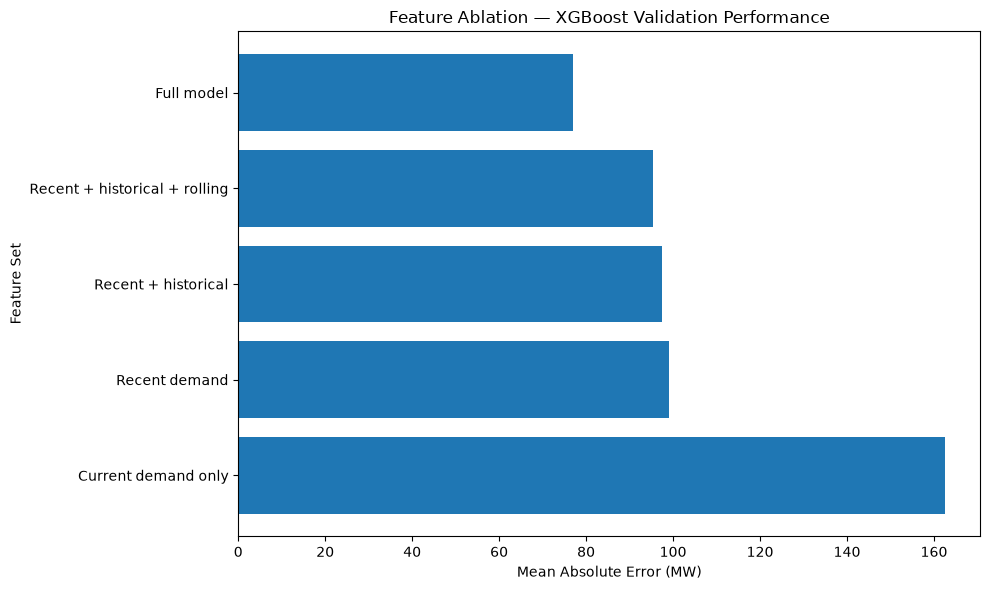

In [10]:
plot_data = (
    ablation_results
    .sort_values("MAE_MW", ascending=False)
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Feature set"],
    plot_data["MAE_MW"],
)

plt.title("Feature Ablation — XGBoost Validation Performance")
plt.xlabel("Mean Absolute Error (MW)")
plt.ylabel("Feature Set")
plt.tight_layout()
plt.show()

In [11]:
validation["xgb_error"] = (
    validation["target_30m"]
    - validation["xgb_forecast"]
)

validation["xgb_absolute_error"] = (
    validation["xgb_error"].abs()
)

validation["target_hour"] = (
    validation["FORECAST_TIME"].dt.hour
)

xgb_error_by_hour = (
    validation.groupby("target_hour")
    .agg(
        MAE=("xgb_absolute_error", "mean"),
        RMSE=(
            "xgb_error",
            lambda x: np.sqrt(np.mean(x**2)),
        ),
    )
)

xgb_error_by_hour

,MAE,RMSE
target_hour,,
0,43.691441,53.717479
1,38.451836,47.567441
2,43.195121,54.564192
3,42.598181,55.271346
4,48.851728,61.231262
5,52.443418,65.585108
6,69.022312,86.641874
7,101.091305,126.080315
8,107.122553,134.527811


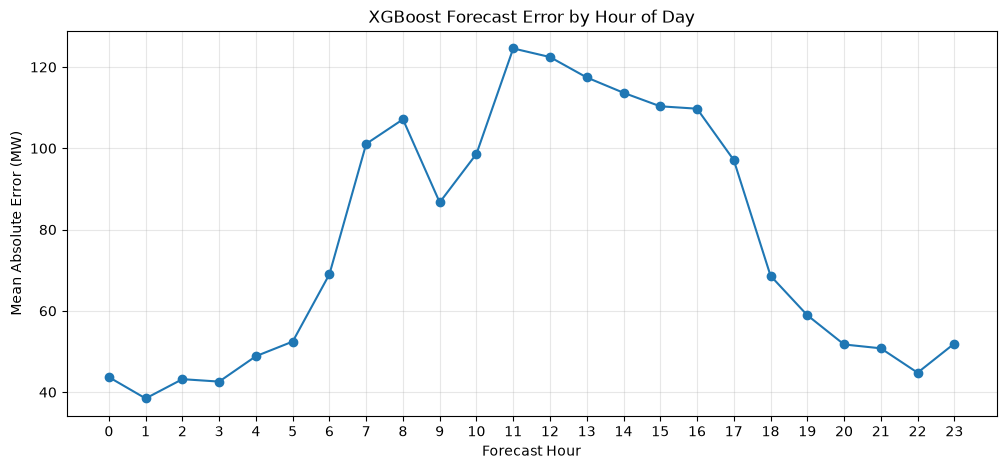

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    xgb_error_by_hour.index,
    xgb_error_by_hour["MAE"],
    marker="o",
)

plt.title("XGBoost Forecast Error by Hour of Day")
plt.xlabel("Forecast Hour")
plt.ylabel("Mean Absolute Error (MW)")
plt.xticks(range(24))
plt.grid(alpha=0.3)
plt.show()

### Feature ablation and error analysis

The feature ablation study shows that recent demand dynamics provide most of
the initial improvement over persistence. Using recent demand and rate-of-change
features reduces validation MAE from approximately 162.5 MW to 99.1 MW.

Historical demand at comparable times and rolling statistics provide smaller
incremental improvements, reducing MAE further to approximately 95.4 MW.

Calendar context provides the largest additional improvement. Adding information
about forecast hour, minute, day of week, month and weekend status reduces MAE
from approximately 95.4 MW to 77.1 MW.

This indicates that short-term electricity demand is driven by both recent
trajectory and systematic temporal behaviour.

XGBoost also substantially reduces forecast error during several periods that
were difficult for linear regression, including the morning demand ramp and
late-evening period. The model's largest remaining errors are concentrated
roughly between late morning and the afternoon, suggesting that external
drivers such as weather may provide additional predictive information.

In [14]:
import holidays


vic_holidays = holidays.Australia(
    years=[2024, 2025, 2026],
    subdiv="VIC",
)

holiday_table = pd.DataFrame(
    [
        {
            "date": date,
            "holiday": name,
        }
        for date, name in sorted(vic_holidays.items())
    ]
)

holiday_table

,date,holiday
0,2024-01-01,New Year's Day
1,2024-01-26,Australia Day
2,2024-03-11,Labour Day
3,2024-03-29,Good Friday
4,2024-03-30,Easter Saturday
5,2024-03-31,Easter Sunday
6,2024-04-01,Easter Monday
7,2024-04-25,ANZAC Day
8,2024-06-10,King's Birthday
9,2024-09-27,Friday before the AFL Grand Final


In [15]:
train["target_is_public_holiday"] = (
    train["FORECAST_TIME"]
    .dt.date
    .map(lambda date: int(date in vic_holidays))
)

validation["target_is_public_holiday"] = (
    validation["FORECAST_TIME"]
    .dt.date
    .map(lambda date: int(date in vic_holidays))
)

print(
    "Training holiday observations:",
    train["target_is_public_holiday"].sum(),
)

print(
    "Validation holiday observations:",
    validation["target_is_public_holiday"].sum(),
)

Training holiday observations: 5472
Validation holiday observations: 1728


In [16]:
validation.loc[
    validation["target_is_public_holiday"] == 1,
    ["FORECAST_TIME"]
].assign(
    date=lambda x: x["FORECAST_TIME"].dt.date,
).drop_duplicates(
    subset="date"
)

,FORECAST_TIME,date
177401,2026-03-09,2026-03-09
184601,2026-04-03,2026-04-03
184889,2026-04-04,2026-04-04
185177,2026-04-05,2026-04-05
185465,2026-04-06,2026-04-06
190937,2026-04-25,2026-04-25


In [17]:
holiday_features = features + [
    "target_is_public_holiday",
]

holiday_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

holiday_model.fit(
    train[holiday_features],
    train["target_30m"],
)

validation["holiday_xgb_forecast"] = (
    holiday_model.predict(
        validation[holiday_features]
    )
)

holiday_mae = mean_absolute_error(
    validation["target_30m"],
    validation["holiday_xgb_forecast"],
)

holiday_rmse = np.sqrt(
    mean_squared_error(
        validation["target_30m"],
        validation["holiday_xgb_forecast"],
    )
)

print(f"Original XGBoost MAE:  {xgb_mae:.1f} MW")
print(f"Holiday XGBoost MAE:   {holiday_mae:.1f} MW")
print()
print(f"Original XGBoost RMSE: {xgb_rmse:.1f} MW")
print(f"Holiday XGBoost RMSE:  {holiday_rmse:.1f} MW")

Original XGBoost MAE:  77.2 MW
Holiday XGBoost MAE:   77.4 MW

Original XGBoost RMSE: 107.5 MW
Holiday XGBoost RMSE:  107.7 MW


In [18]:
holiday_mae_change = (
    (xgb_mae - holiday_mae)
    / xgb_mae
    * 100
)

holiday_rmse_change = (
    (xgb_rmse - holiday_rmse)
    / xgb_rmse
    * 100
)

holiday_comparison = pd.DataFrame(
    {
        "Model": [
            "XGBoost",
            "XGBoost + public holiday",
        ],
        "MAE_MW": [
            xgb_mae,
            holiday_mae,
        ],
        "RMSE_MW": [
            xgb_rmse,
            holiday_rmse,
        ],
    }
)

display(holiday_comparison)

print(
    f"MAE improvement from holiday feature: "
    f"{holiday_mae_change:.2f}%"
)

print(
    f"RMSE improvement from holiday feature: "
    f"{holiday_rmse_change:.2f}%"
)

,Model,MAE_MW,RMSE_MW
0,XGBoost,77.245516,107.458023
1,XGBoost + public holiday,77.426084,107.747037


MAE improvement from holiday feature: -0.23%
RMSE improvement from holiday feature: -0.27%


### Public-holiday feature

A Victorian public-holiday indicator was tested as an additional calendar
feature.

The feature did not improve validation performance:

- Original XGBoost MAE: 77.25 MW
- XGBoost + public holiday MAE: 77.43 MW

This represents a small deterioration of approximately 0.23%.

The holiday indicator is therefore excluded from the current model
specification. Public-holiday effects may already be partly captured by
existing day-of-week and weekend variables, while the relatively small
number of holidays limits the amount of information available to estimate
a distinct effect reliably.